In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

In [2]:
df = pd.read_csv("<your path for final dataset>", sep=None, engine="python")
df.shape

(608304, 45)

In [3]:
y = df["is_alarm"]
X = df.drop(["is_alarm"], axis=1)
X = X.select_dtypes(include=[np.number]) 

# REMOVE NAN

data = pd.concat([X, y], axis=1)
data = data.dropna()
X = data.drop("is_alarm", axis=1)
y = data["is_alarm"]
feature_names = X.columns.tolist()
print("Dataset shape after removing NaN:", data.shape)
print("Number of features:", len(feature_names))

Dataset shape after removing NaN: (21625, 31)
Number of features: 30


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tscv = TimeSeriesSplit(n_splits=5)
splits = []

In [5]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

best_model = None
best_score = 0
best_params = None

TRAIN WITH CROSS-VALIDATION

In [6]:
for train_index, test_index in tscv.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    splits.append((train_index, test_index))

last_train, last_test = splits[-1]
X_train, X_test = X_scaled[last_train], X_scaled[last_test]
y_train, y_test = y.iloc[last_train], y.iloc[last_test]

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for m in param_grid["min_samples_split"]:
            model = RandomForestClassifier(
                n_estimators=n,
                max_depth=d,
                min_samples_split=m,
                random_state=42,
                class_weight="balanced"
            )
            model.fit(X_train, y_train)
            score = model.score(X_test, y_test)
            if score > best_score:
                best_score = score
                best_model = model
                best_params = {"n_estimators": n, "max_depth": d, "min_samples_split": m}

print("\nBest Hyperparameters:", best_params)
print("Best Accuracy on last split:", best_score)


Best Hyperparameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
Best Accuracy on last split: 0.9697558268590455


FINAL MODEL

In [7]:
final_model = best_model
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:,1]

METRICS

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nMetrics on last split:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")



Metrics on last split:
Accuracy: 0.9698
Precision: 0.9698
Recall: 1.0000
F1-score: 0.9846


CONFUSION MATRIX


Confusion Matrix:
 [[   0  109]
 [   0 3495]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       109
         1.0       0.97      1.00      0.98      3495

    accuracy                           0.97      3604
   macro avg       0.48      0.50      0.49      3604
weighted avg       0.94      0.97      0.95      3604


/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


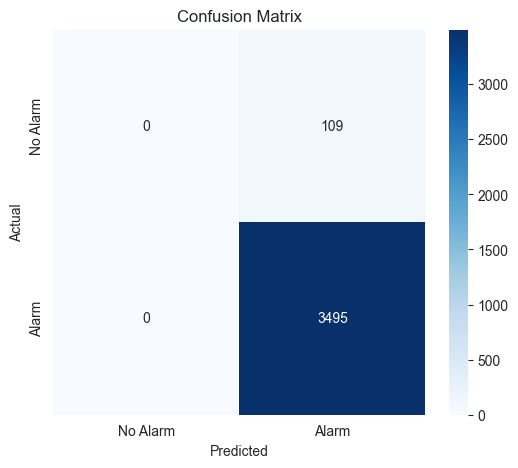

In [9]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Alarm","Alarm"],
            yticklabels=["No Alarm","Alarm"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

FEATURE IMPORTANCE

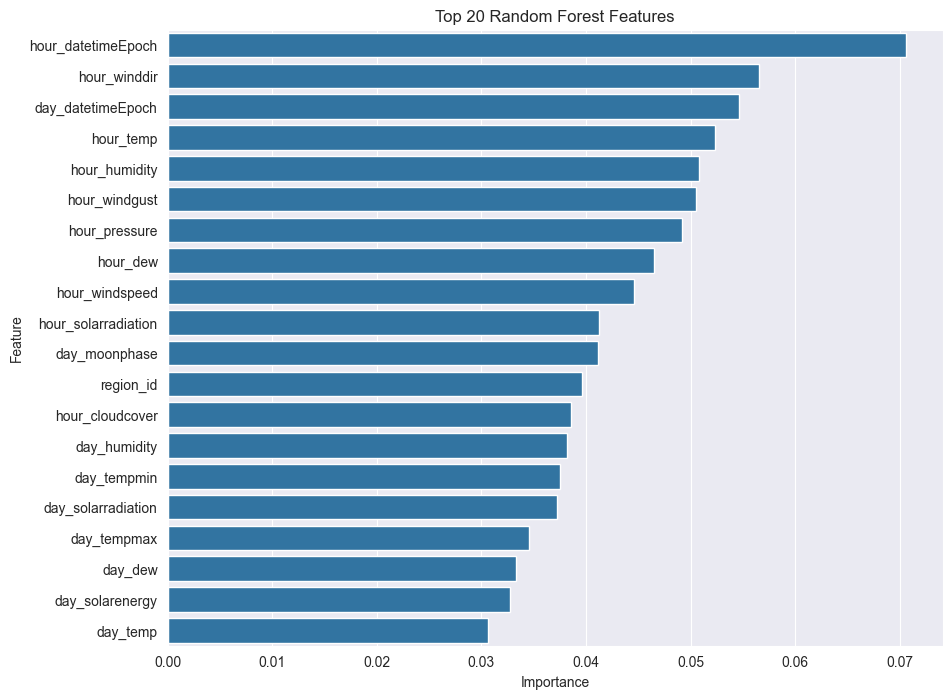

In [10]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
top20 = importance.head(20)

plt.figure(figsize=(10,8))
sns.barplot(data=top20, x="Importance", y="Feature")
plt.title("Top 20 Random Forest Features")
plt.show()

ROC Curve

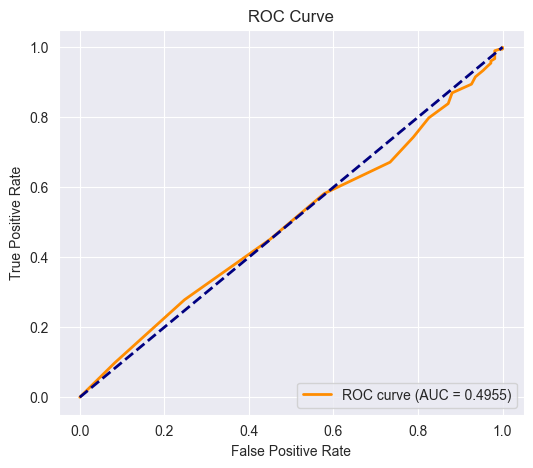

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

Precision-Recall Curve

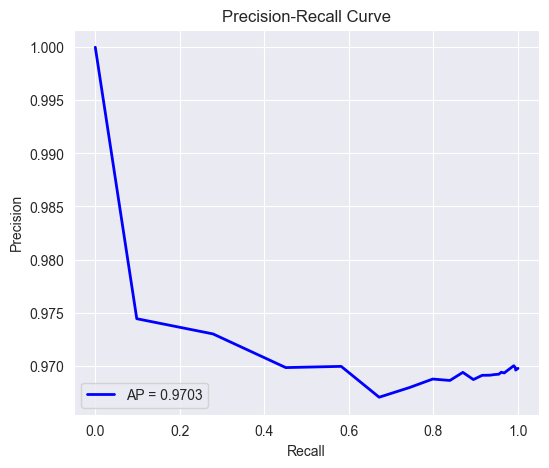

In [12]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_proba)
avg_prec = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'AP = {avg_prec:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()